In [ ]:
import pandas as pd

# Load the training dataset
train_df = pd.read_csv('/content/UNSW_NB15_training-set(in).csv', encoding='latin1')

# Load the testing dataset
test_df = pd.read_csv('/content/UNSW_NB15_testing-set(in).csv', encoding='latin1')

# Combine the two datasets
combined_df = pd.concat([train_df, test_df], ignore_index=True)

print(f"Shape of training dataset: {train_df.shape}")
print(f"Shape of testing dataset: {test_df.shape}")
print(f"Shape of combined dataset: {combined_df.shape}")

# Display the first 5 rows of the combined dataset
display(combined_df.head())

Shape of training dataset: (175341, 45)
Shape of testing dataset: (82332, 45)
Shape of combined dataset: (257673, 45)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


In [ ]:
import pandas as pd

train_raw = pd.read_csv("UNSW_NB15_training-set(in).csv")
test_raw  = pd.read_csv("UNSW_NB15_testing-set(in).csv")

print(train_raw.shape, test_raw.shape)


(175341, 45) (82332, 45)


In [ ]:
combined = pd.concat([train_raw, test_raw], ignore_index=True)
print("Full combined shape:", combined.shape)


Full combined shape: (257673, 45)


In [ ]:
duplicates_within = combined.duplicated().sum()
print("Duplicates within combined:", duplicates_within)


Duplicates within combined: 0


In [ ]:
train_features = train_raw.drop(columns=['id'])
test_features  = test_raw.drop(columns=['id'])

merged = pd.merge(train_features, test_features, how='inner')
print("Overlapping rows:", merged.shape[0])


Overlapping rows: 109106


In [ ]:
import pandas as pd

# Load RAW original datasets again (must be raw, unchanged)
train_raw = pd.read_csv("UNSW_NB15_training-set(in).csv")
test_raw  = pd.read_csv("UNSW_NB15_testing-set(in).csv")

print("Train shape:", train_raw.shape)
print("Test shape:", test_raw.shape)

# ---- STEP 1: Drop ONLY id column (as Gemini did) ----
train_feat = train_raw.drop(columns=['id'])
test_feat  = test_raw.drop(columns=['id'])

# ---- STEP 2: Ensure columns match EXACTLY in order ----
test_feat = test_feat[train_feat.columns]

# ---- STEP 3: Convert rows to tuples for fast comparison ----
train_tuples = set(map(tuple, train_feat.to_numpy()))
test_tuples  = list(map(tuple, test_feat.to_numpy()))

# ---- STEP 4: Build mask: True means KEEP ----
mask = [row not in train_tuples for row in test_tuples]

# ---- STEP 5: Apply mask to filter ----
test_filtered = test_raw[mask]

print("Original Test rows:", len(test_raw))
print("Filtered Test rows:", len(test_filtered))
print("Rows removed:", len(test_raw) - len(test_filtered))


Train shape: (175341, 45)
Test shape: (82332, 45)
Original Test rows: 82332
Filtered Test rows: 78085
Rows removed: 4247


In [ ]:
# Save the processed datasets
train_processed_df = train_raw.copy()
test_processed_df  = test_filtered.copy()

train_processed_df.to_csv("UNSW_NB15_training_processed.csv", index=False)
test_processed_df.to_csv("UNSW_NB15_testing_filtered.csv", index=False)

print("Saved:")
print("  UNSW_NB15_training_processed.csv:", train_processed_df.shape)
print("  UNSW_NB15_testing_filtered.csv:", test_processed_df.shape)


Saved:
  UNSW_NB15_training_processed.csv: (175341, 45)
  UNSW_NB15_testing_filtered.csv: (78085, 45)


In [ ]:
from google.colab import files

files.download("UNSW_NB15_training_processed.csv")
files.download("UNSW_NB15_testing_filtered.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
duplicate_rows = combined_df[combined_df.duplicated()]
num_duplicates = len(duplicate_rows)

print(f"Number of duplicate rows in the combined dataset: {num_duplicates}")

Number of duplicate rows in the combined dataset: 0


In [ ]:
# Define feature columns (all columns except 'id', 'attack_cat', 'label')
feature_columns = [col for col in combined_df.columns if col not in ['id', 'attack_cat', 'label']]

# Create DataFrames with only feature columns from train_df and test_df
# Use .copy() to ensure these are independent copies
train_features_only = train_df[feature_columns].copy()
test_features_only = test_df[feature_columns].copy()

# Remove duplicates from train_features_only to get a unique set of training features
unique_train_features_set = train_features_only.drop_duplicates()

# Perform a left merge of test_features_only with unique_train_features_set.
# Use an indicator to mark rows that are only in the left DataFrame (test_features_only).
# Resetting the index before merge ensures proper alignment and allows retaining original indices.
merged_to_filter_test = pd.merge(
    test_features_only.reset_index(), # Left DataFrame (test features with original index)
    unique_train_features_set.reset_index(drop=True), # Right DataFrame (unique train features)
    on=feature_columns,
    how='left',
    indicator=True
)

# Filter for rows that are 'left_only' (i.e., present in test_features_only but NOT in unique_train_features_set)
# These are the rows in the test set whose features are distinct from the training set's features.
distinct_test_rows_info = merged_to_filter_test[merged_to_filter_test['_merge'] == 'left_only']

# Get the original indices from the test_df that correspond to these distinct rows
indices_to_keep_in_test = distinct_test_rows_info['index']

# Create the new, filtered testing dataset by selecting rows from the original test_df
test_df_filtered = test_df.loc[indices_to_keep_in_test].copy()

print(f"Original number of rows in testing dataset: {len(test_df)}")
print(f"Number of rows in the testing dataset after removing feature-wise overlapping rows with training set: {len(test_df_filtered)}")

# Now, combine the original training dataset with the newly filtered testing dataset
combined_df_filtered = pd.concat([train_df, test_df_filtered], ignore_index=True)
print(f"Number of rows in the new combined dataset (original training + filtered testing): {len(combined_df_filtered)}")

# Display the first few rows of the filtered test dataset
display(test_df_filtered.head())

Original number of rows in testing dataset: 82332
Number of rows in the testing dataset after removing feature-wise overlapping rows with training set: 73791
Number of rows in the new combined dataset (original training + filtered testing): 249132


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


In [ ]:
import pandas as pd

# Load the processed training dataset
train_processed_df = pd.read_csv('UNSW_NB15_training_processed.csv')

print(f"Shape of the processed training dataset: {train_processed_df.shape}")
display(train_processed_df.head())

Shape of the processed training dataset: (175341, 45)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


In [ ]:
import pandas as pd

# Load the processed testing dataset
test_processed_df = pd.read_csv('UNSW_NB15_testing_filtered.csv')

print(f"Shape of the processed testing dataset: {test_processed_df.shape}")
display(test_processed_df.head())

Shape of the processed testing dataset: (78085, 45)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


In [ ]:
import os
import xgboost as xgb
import shap
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder

In [ ]:
# ---------- CONFIG ----------
TRAIN_CSV = "UNSW_NB15_training_processed.csv"   # processed training dataset
TEST_CSV  = "UNSW_NB15_testing_filtered.csv"     # processed testing dataset
TARGET_COL = "label"      # target column in both CSVs
TOP_K = 20                # number of top features to keep
RANDOM_STATE = 42

In [ ]:
# ---------- STEP 0: Load CSVs ----------
if not os.path.exists(TRAIN_CSV):
    raise FileNotFoundError(f"Train file not found: {TRAIN_CSV}")
if not os.path.exists(TEST_CSV):
    raise FileNotFoundError(f"Test file not found: {TEST_CSV}")

In [ ]:
# Load processed training and testing datasets
df_train = pd.read_csv(TRAIN_CSV)
print(f"Shape of the processed training dataset: {df_train.shape}")
display(df_train.head())

df_test_external = pd.read_csv(TEST_CSV)
print(f"Shape of the processed testing dataset: {df_test_external.shape}")
display(df_test_external.head())

Shape of the processed training dataset: (175341, 45)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


Shape of the processed testing dataset: (78085, 45)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


In [ ]:
print("\n=== TRAINING INFO ===")
train_df.info()

print("\n=== TESTING INFO ===")
test_df.info()

print("\n=== Missing values in Training ===")
print(train_df.isnull().sum())

print("\n=== Missing values in Testing ===")
print(test_df.isnull().sum())



=== TRAINING INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 45 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 175341 non-null  int64  
 1   dur                175341 non-null  float64
 2   proto              175341 non-null  object 
 3   service            175341 non-null  object 
 4   state              175341 non-null  object 
 5   spkts              175341 non-null  int64  
 6   dpkts              175341 non-null  int64  
 7   sbytes             175341 non-null  int64  
 8   dbytes             175341 non-null  int64  
 9   rate               175341 non-null  float64
 10  sttl               175341 non-null  int64  
 11  dttl               175341 non-null  int64  
 12  sload              175341 non-null  float64
 13  dload              175341 non-null  float64
 14  sloss              175341 non-null  int64  
 15  dloss              175341 no

In [ ]:
print("\nTraining target distribution:")
print(train_df['label'].value_counts())

print("\nTesting target distribution:")
print(test_df['label'].value_counts())



Training target distribution:
label
1    119341
0     56000
Name: count, dtype: int64

Testing target distribution:
label
1    45332
0    37000
Name: count, dtype: int64


In [ ]:
if 'attack_cat' in train_df.columns:
    print("attack_cat exists — MUST be dropped before model training.")


attack_cat exists — MUST be dropped before model training.


In [ ]:
train_df_backup = train_df.copy()
test_df_backup  = test_df.copy()


In [ ]:
cols_to_drop = []
if 'attack_cat' in train_df.columns:
    cols_to_drop.append('attack_cat')
if 'id' in train_df.columns:
    cols_to_drop.append('id')

print("Dropping columns:", cols_to_drop)

train_df = train_df.drop(columns=cols_to_drop, errors='ignore')
test_df  = test_df.drop(columns=cols_to_drop, errors='ignore')

print("\nNew shapes -> train:", train_df.shape, ", test:", test_df.shape)


Dropping columns: ['attack_cat', 'id']

New shapes -> train: (175341, 43) , test: (82332, 43)


Train label counts:
 label
1    119341
0     56000
Name: count, dtype: int64

Test label counts:
 label
1    45332
0    37000
Name: count, dtype: int64


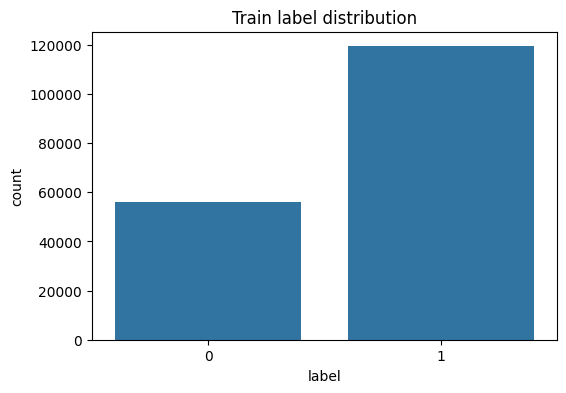

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Train label counts:\n", train_df['label'].value_counts())
print("\nTest label counts:\n", test_df['label'].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x='label', data=train_df)
plt.title("Train label distribution")
plt.show()


In [ ]:
# dtypes and categorical columns
print(train_df.dtypes.value_counts())
cat_cols = train_df.select_dtypes(include=['object','category']).columns.tolist()
num_cols = train_df.select_dtypes(include=['number']).columns.tolist()
print("Categorical cols:", cat_cols)
print("Numeric cols count:", len(num_cols))

# check near-constant columns
low_variance = [c for c in train_df.columns if train_df[c].nunique() <= 1]
print("Near-constant cols (<=1 unique):", low_variance)


int64      29
float64    11
object      3
Name: count, dtype: int64
Categorical cols: ['proto', 'service', 'state']
Numeric cols count: 40
Near-constant cols (<=1 unique): []


In [ ]:
# Step 4 - Summary statistics + skewness for numeric features
num_cols = train_df.select_dtypes(include=['number']).columns.tolist()

desc = train_df[num_cols].describe().T
desc['skew'] = train_df[num_cols].skew().round(3)

desc_sorted = desc[['count','mean','std','min','25%','50%','75%','max','skew']] \
                .sort_values('skew', ascending=False)

desc_sorted.head(20)


,count,mean,std,min,25%,50%,75%,max,skew
trans_depth,175341.0,1.059821e-01,7.769108e-01,0.0,0.000000,0.000000,0.000000e+00,1.720000e+02,167.336
response_body_len,175341.0,2.144292e+03,5.420797e+04,0.0,0.000000,0.000000,0.000000e+00,6.558056e+06,76.340
sbytes,175341.0,8.844844e+03,1.747656e+05,28.0,114.000000,430.000000,1.418000e+03,1.296523e+07,45.303
sloss,175341.0,4.953000e+00,6.600506e+01,0.0,0.000000,0.000000,3.000000e+00,4.803000e+03,44.754
dloss,175341.0,6.948010e+00,5.273300e+01,0.0,0.000000,0.000000,2.000000e+00,5.484000e+03,41.380
spkts,175341.0,2.029866e+01,1.368876e+02,1.0,2.000000,2.000000,1.200000e+01,9.616000e+03,40.218
dbytes,175341.0,1.492892e+04,1.436542e+05,0.0,0.000000,164.000000,1.102000e+03,1.465555e+07,39.761
dpkts,175341.0,1.896959e+01,1.102583e+02,0.0,0.000000,2.000000,1.000000e+01,1.097400e+04,36.764
dinpkt,175341.0,8.821630e+01,9.870932e+02,0.0,0.000000,0.006000,5.105300e+01,5.671682e+04,29.680
djit,175341.0,6.043538e+02,4.061043e+03,0.0,0.000000,0.000000,1.149906e+02,2.893883e+05,29.544


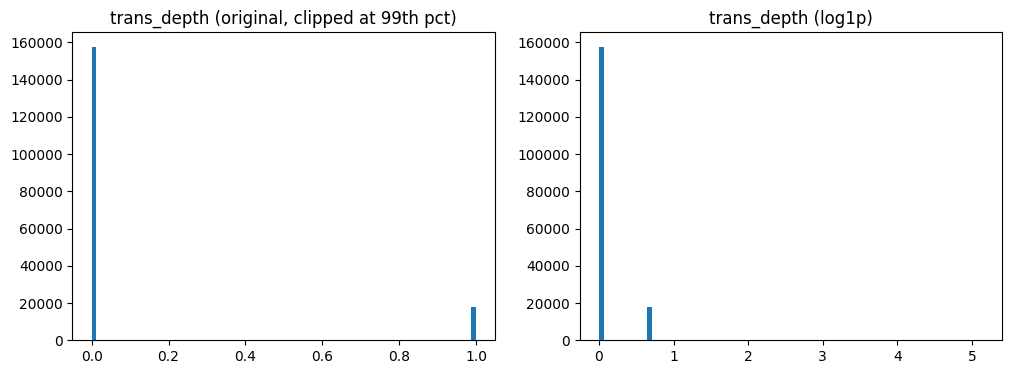

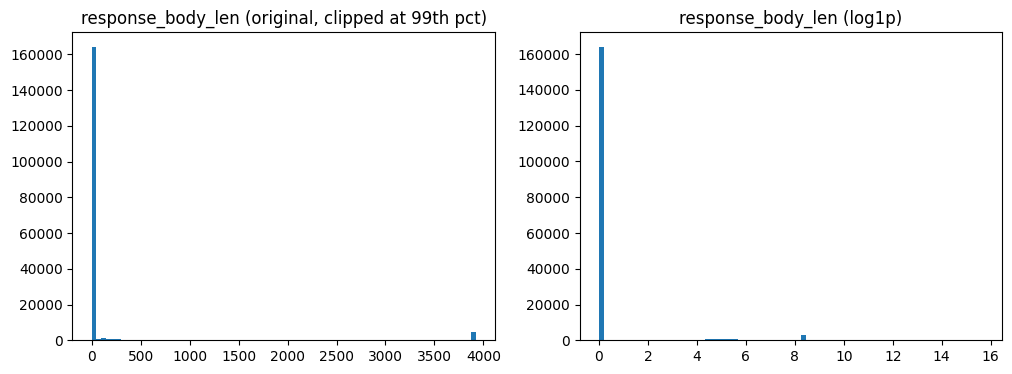

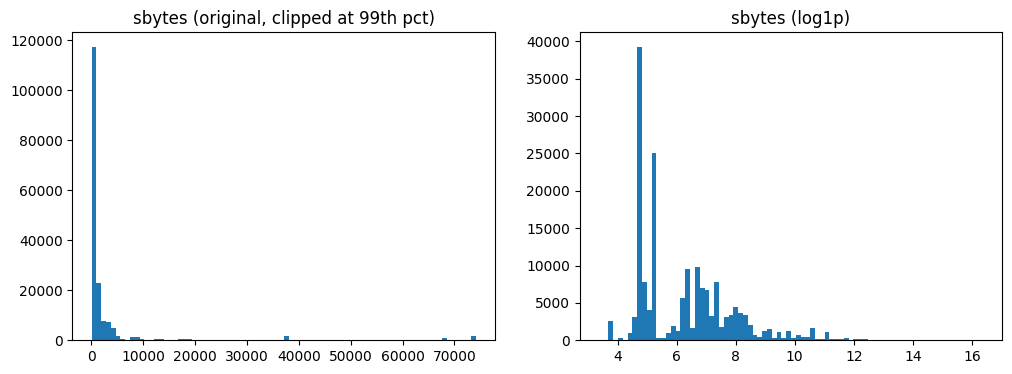

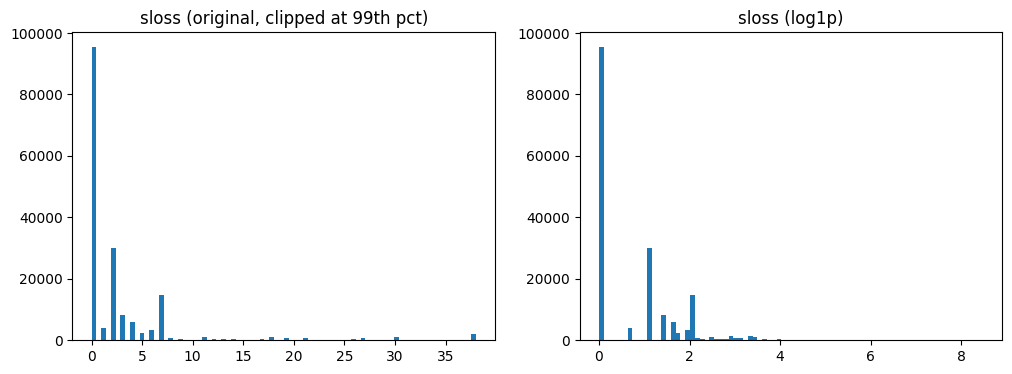

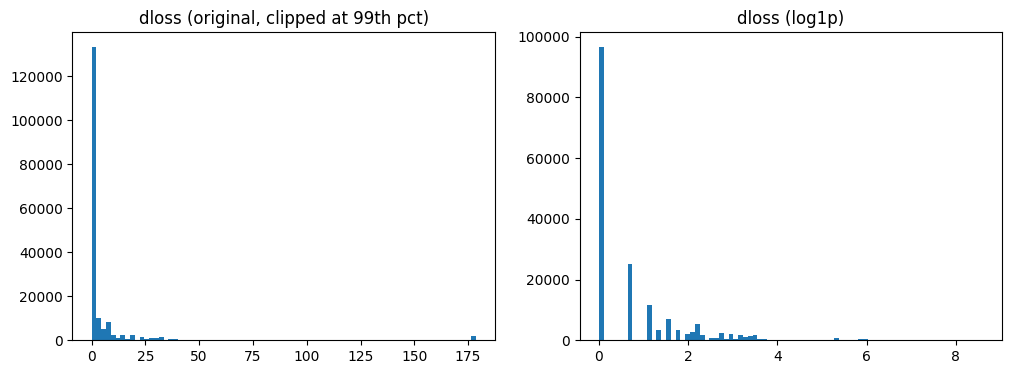

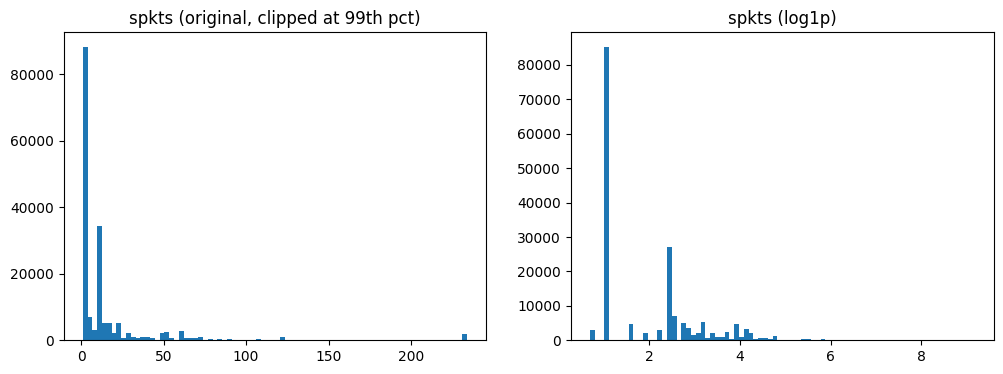

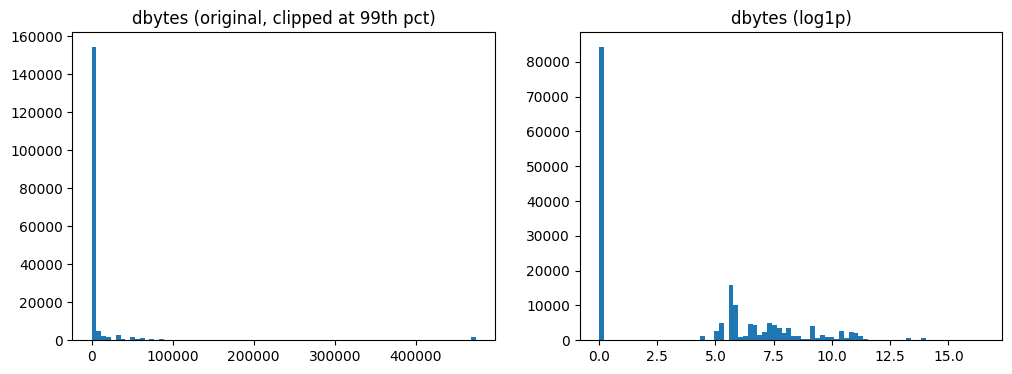

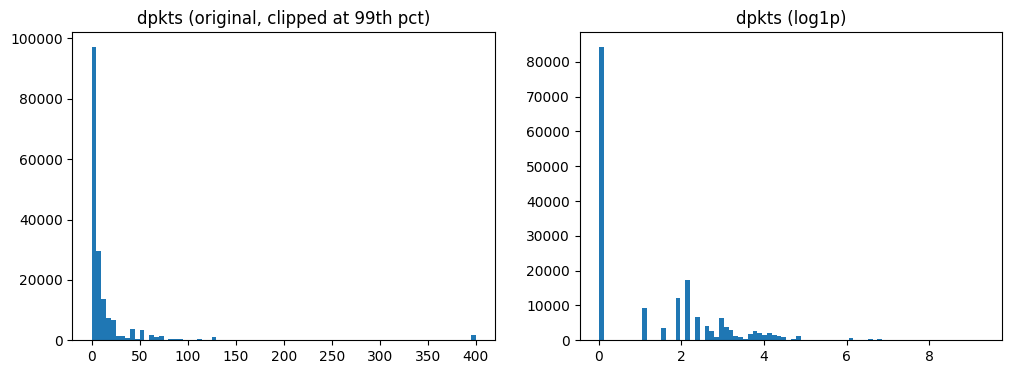

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

top_skewed = [
    'trans_depth', 'response_body_len', 'sbytes', 'sloss',
    'dloss', 'spkts', 'dbytes', 'dpkts'
]

for col in top_skewed:
    data = train_df[col]
    plt.figure(figsize=(12,4))

    # original distribution (clipped)
    plt.subplot(1,2,1)
    plt.hist(data.clip(upper=data.quantile(0.99)), bins=80)
    plt.title(f"{col} (original, clipped at 99th pct)")

    # log-transformed
    plt.subplot(1,2,2)
    plt.hist(np.log1p(data), bins=80)
    plt.title(f"{col} (log1p)")

    plt.show()


In [ ]:
import numpy as np

log_features = [
    'trans_depth', 'response_body_len', 'sbytes', 'sloss', 'dloss',
    'spkts', 'dbytes', 'dpkts', 'dinpkt', 'djit',
    'sload', 'sinpkt', 'dur'
]

log_features = [c for c in log_features if c in train_df.columns]

print("Applying log1p to:", log_features)

for col in log_features:
    train_df[col + "_log"] = np.log1p(train_df[col])
    test_df[col + "_log"]  = np.log1p(test_df[col])


Applying log1p to: ['trans_depth', 'response_body_len', 'sbytes', 'sloss', 'dloss', 'spkts', 'dbytes', 'dpkts', 'dinpkt', 'djit', 'sload', 'sinpkt', 'dur']


In [ ]:
for col in ['proto', 'service', 'state']:
    print(f"\n====== {col.upper()} (TRAIN) ======")
    print(train_df[col].value_counts().head(20))
    print(f"Unique values: {train_df[col].nunique()}")



====== PROTO (TRAIN) ======
proto
tcp        79946
udp        63283
unas       12084
arp         2859
ospf        2595
sctp        1150
any          300
gre          225
ipv6         201
mobile       201
pim          201
swipe        201
sun-nd       201
rsvp         200
sep          193
ib           101
iplt         100
cphb         100
iso-ip       100
sat-mon      100
Name: count, dtype: int64
Unique values: 133

====== SERVICE (TRAIN) ======
service
-           94168
dns         47294
http        18724
smtp         5058
ftp-data     3995
ftp          3428
ssh          1302
pop3         1105
dhcp           94
snmp           80
ssl            56
irc            25
radius         12
Name: count, dtype: int64
Unique values: 13

====== STATE (TRAIN) ======
state
INT    82275
FIN    77825
CON    13152
REQ     1991
RST       83
ECO       12
PAR        1
URN        1
no         1
Name: count, dtype: int64
Unique values: 9


In [ ]:
from sklearn.preprocessing import LabelEncoder

cat_cols = ['proto', 'service', 'state']
encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    combined = pd.concat([train_df[col], test_df[col]], axis=0).astype(str)   # avoid unseen errors
    le.fit(combined)

    train_df[col + "_enc"] = le.transform(train_df[col].astype(str))
    test_df[col  + "_enc"] = le.transform(test_df[col].astype(str))

    encoders[col] = le

print("Encoded columns created:", [c+"_enc" for c in cat_cols])


Encoded columns created: ['proto_enc', 'service_enc', 'state_enc']


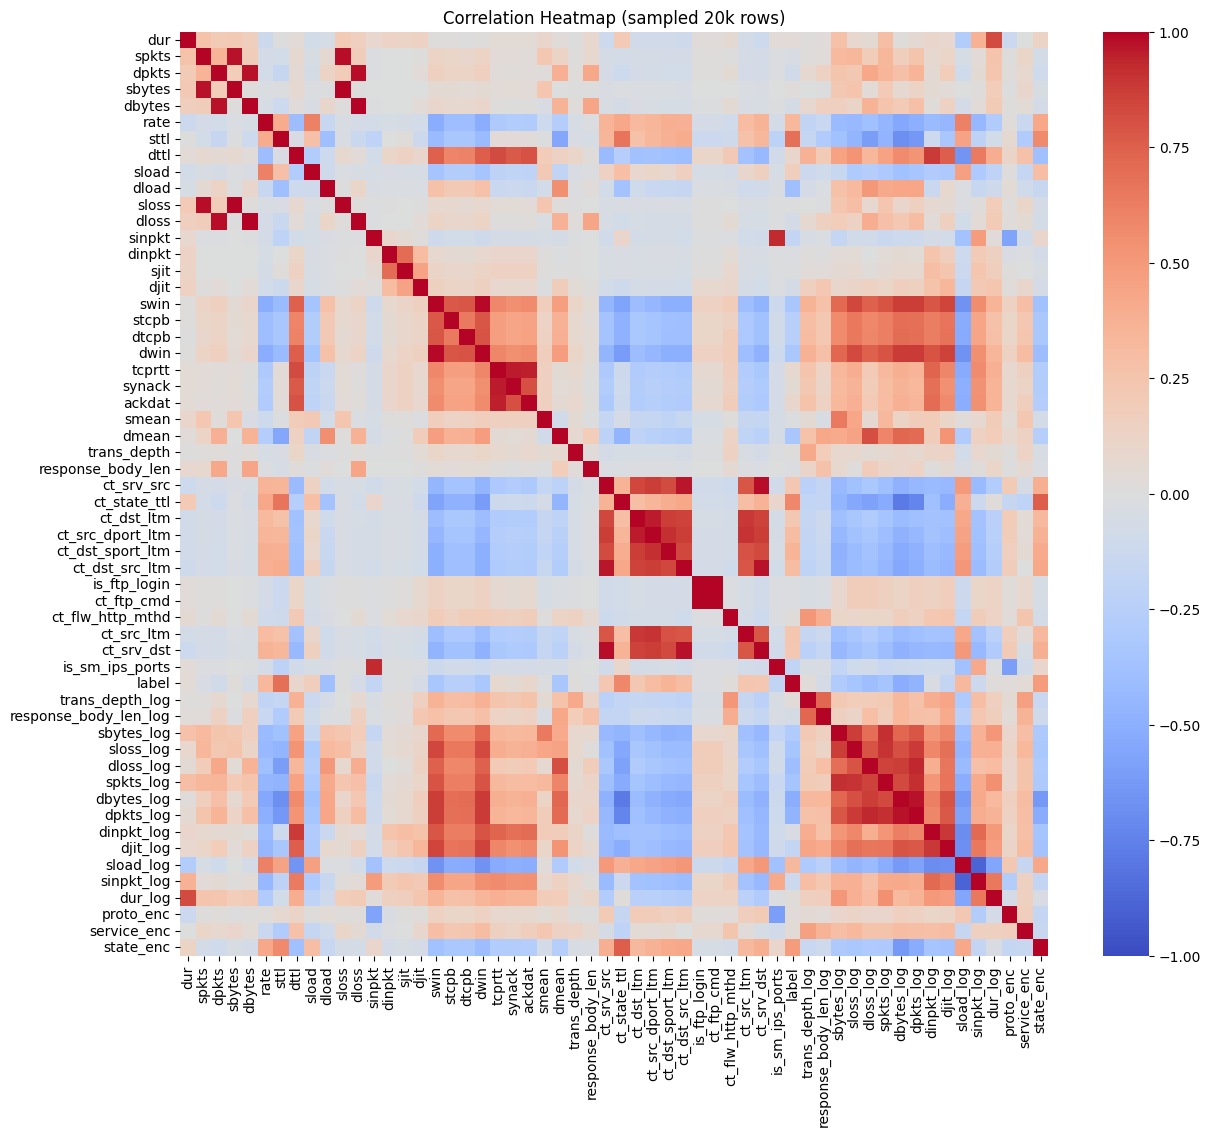


🔥 Highly correlated feature pairs (>|0.90|):
('spkts', 'sbytes', np.float64(0.974))
('spkts', 'sloss', np.float64(0.978))
('dpkts', 'dbytes', np.float64(0.976))
('dpkts', 'dloss', np.float64(0.98))
('sbytes', 'sloss', np.float64(0.998))
('dbytes', 'dloss', np.float64(0.998))
('sinpkt', 'is_sm_ips_ports', np.float64(0.928))
('swin', 'dwin', np.float64(0.991))
('tcprtt', 'synack', np.float64(0.954))
('tcprtt', 'ackdat', np.float64(0.946))
('ct_srv_src', 'ct_dst_src_ltm', np.float64(0.967))
('ct_srv_src', 'ct_srv_dst', np.float64(0.981))
('ct_dst_ltm', 'ct_src_dport_ltm', np.float64(0.961))
('ct_src_dport_ltm', 'ct_dst_sport_ltm', np.float64(0.907))
('ct_dst_src_ltm', 'ct_srv_dst', np.float64(0.972))
('is_ftp_login', 'ct_ftp_cmd', np.float64(1.0))
('sbytes_log', 'spkts_log', np.float64(0.908))
('sloss_log', 'spkts_log', np.float64(0.905))
('dloss_log', 'dpkts_log', np.float64(0.93))
('spkts_log', 'dpkts_log', np.float64(0.907))
('dbytes_log', 'dpkts_log', np.float64(0.973))


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Step 9 — Correlation on numeric + encoded features only
num_and_enc_cols = train_df.select_dtypes(include=['number']).columns.tolist()

# take a sample to make heatmap faster
sample_df = train_df[num_and_enc_cols].sample(n=min(20000, len(train_df)), random_state=42)

plt.figure(figsize=(14,12))
corr_matrix = sample_df.corr()
sns.heatmap(corr_matrix, cmap='coolwarm', vmax=1, vmin=-1)
plt.title("Correlation Heatmap (sampled 20k rows)")
plt.show()

# find highly correlated pairs
high_corr_pairs = []
threshold = 0.90

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_value = corr_matrix.iloc[i, j]
        if abs(corr_value) > threshold:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                round(corr_value, 3)
            ))

print("\n🔥 Highly correlated feature pairs (>|0.90|):")
for p in high_corr_pairs:
    print(p)


In [ ]:
if 'ct_ftp_cmd' in train_df.columns:
    train_df = train_df.drop(columns=['ct_ftp_cmd'])
    test_df  = test_df.drop(columns=['ct_ftp_cmd'])
    print("Dropped redundant 'ct_ftp_cmd' (correlation 1.0 with is_ftp_login).")


Dropped redundant 'ct_ftp_cmd' (correlation 1.0 with is_ftp_login).


In [ ]:
# All categorical encoded columns
enc_cols = ['proto_enc', 'service_enc', 'state_enc']

# All log-transformed columns
log_cols = [c for c in train_df.columns if c.endswith("_log")]

# Other numeric columns (exclude original categorical columns)
numeric_cols = train_df.select_dtypes(include=['number']).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in enc_cols + ['label']]

# Combine everything
feature_cols = numeric_cols + enc_cols + log_cols

# Remove duplicate column names if any
feature_cols = list(dict.fromkeys(feature_cols))

print("Total features being used:", len(feature_cols))
feature_cols[:40]


Total features being used: 54


['dur',
 'spkts',
 'dpkts',
 'sbytes',
 'dbytes',
 'rate',
 'sttl',
 'dttl',
 'sload',
 'dload',
 'sloss',
 'dloss',
 'sinpkt',
 'dinpkt',
 'sjit',
 'djit',
 'swin',
 'stcpb',
 'dtcpb',
 'dwin',
 'tcprtt',
 'synack',
 'ackdat',
 'smean',
 'dmean',
 'trans_depth',
 'response_body_len',
 'ct_srv_src',
 'ct_state_ttl',
 'ct_dst_ltm',
 'ct_src_dport_ltm',
 'ct_dst_sport_ltm',
 'ct_dst_src_ltm',
 'is_ftp_login',
 'ct_flw_http_mthd',
 'ct_src_ltm',
 'ct_srv_dst',
 'is_sm_ips_ports',
 'trans_depth_log',
 'response_body_len_log']

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
import os

TRAIN_PROCESSED_CSV = 'UNSW_NB15_training_processed.csv'
TEST_FILTERED_CSV = 'UNSW_NB15_testing_filtered.csv'

# Check if processed files exist; if not, regenerate them
if not os.path.exists(TRAIN_PROCESSED_CSV) or not os.path.exists(TEST_FILTERED_CSV):
    print("Processed files not found. Regenerating from raw data...")

    # 1. Load original datasets
    train_df_raw = pd.read_csv('/content/UNSW_NB15_training-set(in).csv', encoding='latin1')
    test_df_raw = pd.read_csv('/content/UNSW_NB15_testing-set(in).csv', encoding='latin1')

    # 2. Filter test_df_raw based on feature overlap with train_df_raw
    feature_cols_overlap = [col for col in train_df_raw.columns if col not in ['id', 'attack_cat', 'label']]

    train_features_only_raw = train_df_raw[feature_cols_overlap].copy()
    test_features_only_raw = test_df_raw[feature_cols_overlap].copy()

    unique_train_features_set_raw = train_features_only_raw.drop_duplicates()

    merged_to_filter_test_raw = pd.merge(
        test_features_only_raw.reset_index(),
        unique_train_features_set_raw.reset_index(drop=True),
        on=feature_cols_overlap,
        how='left',
        indicator=True
    )
    distinct_test_rows_info_raw = merged_to_filter_test_raw[merged_to_filter_test_raw['_merge'] == 'left_only']
    indices_to_keep_in_test_raw = distinct_test_rows_info_raw['index']

    test_df = test_df_raw.loc[indices_to_keep_in_test_raw].copy()
    train_df = train_df_raw.copy()

    # 3. Drop 'attack_cat' and 'id'
    cols_to_drop_initial = []
    if 'attack_cat' in train_df.columns:
        cols_to_drop_initial.append('attack_cat')
    if 'id' in train_df.columns:
        cols_to_drop_initial.append('id')
    train_df = train_df.drop(columns=cols_to_drop_initial, errors='ignore')
    test_df = test_df.drop(columns=cols_to_drop_initial, errors='ignore')

    # 4. Apply log transformations
    log_features = [
        'trans_depth', 'response_body_len', 'sbytes', 'sloss', 'dloss',
        'spkts', 'dbytes', 'dpkts', 'dinpkt', 'djit',
        'sload', 'sinpkt', 'dur'
    ]
    log_features = [c for c in log_features if c in train_df.columns]

    for col in log_features:
        train_df[col + "_log"] = np.log1p(train_df[col])
        test_df[col + "_log"]  = np.log1p(test_df[col])

    # 5. Apply Label Encoding
    cat_cols = ['proto', 'service', 'state']

    for col in cat_cols:
        le = LabelEncoder()
        combined_cat = pd.concat([train_df[col], test_df[col]], axis=0).astype(str)
        le.fit(combined_cat)
        train_df[col + "_enc"] = le.transform(train_df[col].astype(str))
        test_df[col + "_enc"] = le.transform(test_df[col].astype(str))

    # 6. Drop redundant 'ct_ftp_cmd' (if it exists and was correlated)
    if 'ct_ftp_cmd' in train_df.columns:
        train_df = train_df.drop(columns=['ct_ftp_cmd'])
        test_df  = test_df.drop(columns=['ct_ftp_cmd'])

    # Save the processed data for future runs
    train_df.to_csv(TRAIN_PROCESSED_CSV, index=False)
    test_df.to_csv(TEST_FILTERED_CSV, index=False)
    print("Processed files regenerated and saved.")

else:
    print("Loading existing processed files...")
    train_df = pd.read_csv(TRAIN_PROCESSED_CSV)
    test_df = pd.read_csv(TEST_FILTERED_CSV)

# --- Define feature_cols based on the (re)loaded/regenerated train_df ---
enc_cols = [col for col in train_df.columns if col.endswith('_enc')]
log_cols = [col for col in train_df.columns if col.endswith('_log')]

original_cat_cols = ['proto', 'service', 'state'] # These were the original categorical columns
numeric_cols = train_df.select_dtypes(include=['number']).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in original_cat_cols + ['label', 'id', 'ct_ftp_cmd']]

feature_cols = numeric_cols + enc_cols + log_cols
feature_cols = list(dict.fromkeys(feature_cols)) # Remove duplicates
if 'label' in feature_cols:
    feature_cols.remove('label')

print(f"Total features identified for model: {len(feature_cols)}")

# --- Perform Train/Validation Split ---
X = train_df[feature_cols]
y = train_df['label']

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Shapes:")
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)

Loading existing processed files...
Total features identified for model: 38
Shapes:
X_train: (140272, 38)
X_val: (35069, 38)


In [ ]:
model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
    tree_method='hist'   # for speed
)

model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_val)

print("\nBaseline Accuracy on Validation Set:", accuracy_score(y_val, y_pred))
print("\nClassification Report:\n", classification_report(y_val, y_pred))


Baseline Accuracy on Validation Set: 0.9595939433687872

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.92      0.94     11200
           1       0.96      0.98      0.97     23869

    accuracy                           0.96     35069
   macro avg       0.96      0.95      0.95     35069
weighted avg       0.96      0.96      0.96     35069



In [ ]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) create explainer using callable predict_proba
background = X_train.sample(n=200, random_state=42)
explainer = shap.Explainer(model.predict_proba, background)   # robust, avoids booster parsing issues

# 2) compute SHAP for a validation sample
n = min(2000, X_val.shape[0])
X_val_sample = X_val.iloc[:n]
shap_explanation = explainer(X_val_sample)

print("Type of shap_explanation:", type(shap_explanation))
print("shap_explanation.values shape:", getattr(shap_explanation, "values", None).shape)
print("shap_explanation.base_values shape:", getattr(shap_explanation, "base_values", None).shape)

# 3) normalize into older format: list per-class or single array
values = shap_explanation.values  # shape could be (n, n_classes, n_features)

if values is None:
    raise RuntimeError("shap_explanation has no .values - something went wrong")

if values.ndim == 3:
    # multiclass: convert to list-of-arrays per class: [ (n, n_features), ... ]
    shap_values_list = [values[:, c, :] for c in range(values.shape[1])]
else:
    shap_values_list = values  # binary/regression => shape (n, n_features)

# 4) compute mean-abs shap importance (same logic as before)
if isinstance(shap_values_list, list):
    per_class_mean_abs = [np.abs(sv).mean(axis=0) for sv in shap_values_list]
    shap_importance = np.mean(np.stack(per_class_mean_abs, axis=0), axis=0)
else:
    shap_importance = np.abs(shap_values_list).mean(axis=0)

feature_importance = pd.DataFrame({
    'feature': model.get_booster().feature_names,
    'mean_abs_shap': shap_importance
}).sort_values(by='mean_abs_shap', ascending=False).reset_index(drop=True)

print("\nTop 20 features by mean(|SHAP|):")
print(feature_importance.head(20))

# 5) SHAP plots (use shap_explanation to draw directly)
# bar plot (global importance)
plt.figure(figsize=(8,6))
shap.plots.bar(shap_explanation, max_display=20)
plt.show()

# beeswarm (local distribution) - may be slower for many features
plt.figure(figsize=(10,6))
# use the older values if needed: shap.plots.beeswarm accepts Explanation directly
shap.plots.beeswarm(shap_explanation, max_display=20)
plt.show()

PermutationExplainer explainer:   5%|▍         | 91/2000 [00:42<16:45,  1.90it/s]


KeyboardInterrupt: 

In [ ]:
# diagnostic 1: shapes / lengths
print("shap_importance shape:", np.shape(shap_importance))
booster_names = model.get_booster().feature_names
print("len(booster.feature_names):", len(booster_names))
print("len(X_val_sample.columns):", len(X_val_sample.columns))

# show a few names so we can visually check ordering
print("\nFirst 40 booster feature names:")
print(booster_names[:40])

print("\nFirst 40 X_val_sample column names:")
print(list(X_val_sample.columns)[:40])


shap_importance shape: (2,)
len(booster.feature_names): 38
len(X_val_sample.columns): 38

First 40 booster feature names:
['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports']

First 40 X_val_sample column names:
['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_flw_http_mthd'

In [ ]:
# diagnostic 2: set differences
set_booster = set(booster_names)
set_Xcols  = set(X_val_sample.columns)

print("Num features used by booster:", len(set_booster))
print("Num columns in X_val_sample:", len(set_Xcols))

print("\nFeatures in booster but NOT in X_val_sample (up to 20):")
print(list(set_booster - set_Xcols)[:20])

print("\nFeatures in X_val_sample but NOT in booster (up to 20):")
print(list(set_Xcols - set_booster)[:20])


Num features used by booster: 38
Num columns in X_val_sample: 38

Features in booster but NOT in X_val_sample (up to 20):
[]

Features in X_val_sample but NOT in booster (up to 20):
[]


In [ ]:
# Option A: if booster_names length == shap_importance length
if len(booster_names) == shap_importance.shape[0]:
    feat_names = booster_names
else:
    # Option B: get the feature names SHAP reports (when Explanation stores names)
    # shap_explanation.feature_names may exist, otherwise fallback to intersection order
    try:
        shap_feat_names = shap_explanation.feature_names
        print("Using shap_explanation.feature_names (len):", len(shap_feat_names))
        feat_names = shap_feat_names
    except Exception:
        # fallback: use intersection in the order of booster_names
        feat_names = [f for f in booster_names if f in X_val_sample.columns]
        print("Fallback feat_names length (booster ∩ X_val_sample):", len(feat_names))

# trim or align shap_importance if needed
shap_arr = np.array(shap_importance)
if shap_arr.shape[0] != len(feat_names):
    minlen = min(shap_arr.shape[0], len(feat_names))
    print("Aligning lengths by taking first", minlen, "entries")
    feat_names = feat_names[:minlen]
    shap_arr = shap_arr[:minlen]

feature_importance = pd.DataFrame({
    'feature': feat_names,
    'mean_abs_shap': shap_arr
}).sort_values(by='mean_abs_shap', ascending=False).reset_index(drop=True)

print(feature_importance.head(20))


Using shap_explanation.feature_names (len): 38
Aligning lengths by taking first 2 entries
  feature  mean_abs_shap
0     dur       0.014373
1   spkts       0.014373


In [ ]:
import numpy as np
import pandas as pd

# 'shap_explanation' and 'model' already exist in your session
values = shap_explanation.values  # (n_samples, ?, ?)
print("raw values.shape:", values.shape)

# Determine layout and convert to list-of-arrays per class: shap_values_list -> list where each item is (n_samples, n_features)
if values.ndim == 3:
    n0, n1, n2 = values.shape
    # If shape is (n_samples, n_classes, n_features)
    if n1 < n2:  # likely n_classes < n_features -> treat n1 as n_classes
        # values.shape == (n_samples, n_classes, n_features)
        shap_values_list = [ values[:, c, :] for c in range(n1) ]
        print("Interpreted shape as (n_samples, n_classes, n_features). List length:", len(shap_values_list))
    else:
        # values.shape == (n_samples, n_features, n_classes)
        shap_values_list = [ values[:, :, c] for c in range(n2) ]
        print("Interpreted shape as (n_samples, n_features, n_classes). List length:", len(shap_values_list))
else:
    # 2-d case: (n_samples, n_features)
    shap_values_list = values
    print("Interpreted shape as (n_samples, n_features).")

# Now compute mean(|SHAP|) per feature across samples and classes (if multiclass)
if isinstance(shap_values_list, list):
    # each element in list is shape (n_samples, n_features)
    per_class_mean_abs = [ np.abs(sv).mean(axis=0) for sv in shap_values_list ]  # list of (n_features,)
    shap_importance = np.mean(np.stack(per_class_mean_abs, axis=0), axis=0)      # (n_features,)
else:
    shap_importance = np.abs(shap_values_list).mean(axis=0)  # (n_features,)

print("shap_importance shape (should equal number of features):", shap_importance.shape)

# Map to the exact feature names used by the model
xgb_feature_names = model.get_booster().feature_names
print("num xgb feature names:", len(xgb_feature_names))

# Align lengths defensively (trim to min length if necessary)
minlen = min(len(xgb_feature_names), shap_importance.shape[0])
if minlen != len(xgb_feature_names) or minlen != shap_importance.shape[0]:
    print("Warning: length mismatch — aligning to first", minlen, "features")

feat_names_aligned = xgb_feature_names[:minlen]
shap_arr_aligned = shap_importance[:minlen]

feature_importance = pd.DataFrame({
    'feature': feat_names_aligned,
    'mean_abs_shap': shap_arr_aligned
}).sort_values(by='mean_abs_shap', ascending=False).reset_index(drop=True)

print("\nTop 20 SHAP features:")
print(feature_importance.head(20))

# Optional: show bar & beeswarm (if you want them again)
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
shap.plots.bar(shap_explanation, max_display=20)
plt.show()

plt.figure(figsize=(10,6))
shap.plots.beeswarm(shap_explanation, max_display=20)
plt.show()


raw values.shape: (2000, 38, 2)
Interpreted shape as (n_samples, n_features, n_classes). List length: 2
shap_importance shape (should equal number of features): (38,)
num xgb feature names: 38

Top 20 SHAP features:
             feature  mean_abs_shap
0               sttl       0.265018
1              smean       0.027830
2   ct_dst_sport_ltm       0.025379
3       ct_state_ttl       0.023872
4             sbytes       0.021274
5         ct_srv_dst       0.019348
6         ct_srv_src       0.018029
7              dmean       0.014381
8     ct_dst_src_ltm       0.012141
9              sloss       0.010813
10            synack       0.009564
11             dload       0.008645
12        ct_dst_ltm       0.007850
13        ct_src_ltm       0.006829
14            sinpkt       0.006088
15            dbytes       0.005386
16              dttl       0.004937
17             dpkts       0.004403
18              sjit       0.004263
19              swin       0.004187


IndexError: list index out of range

<Figure size 800x600 with 0 Axes>

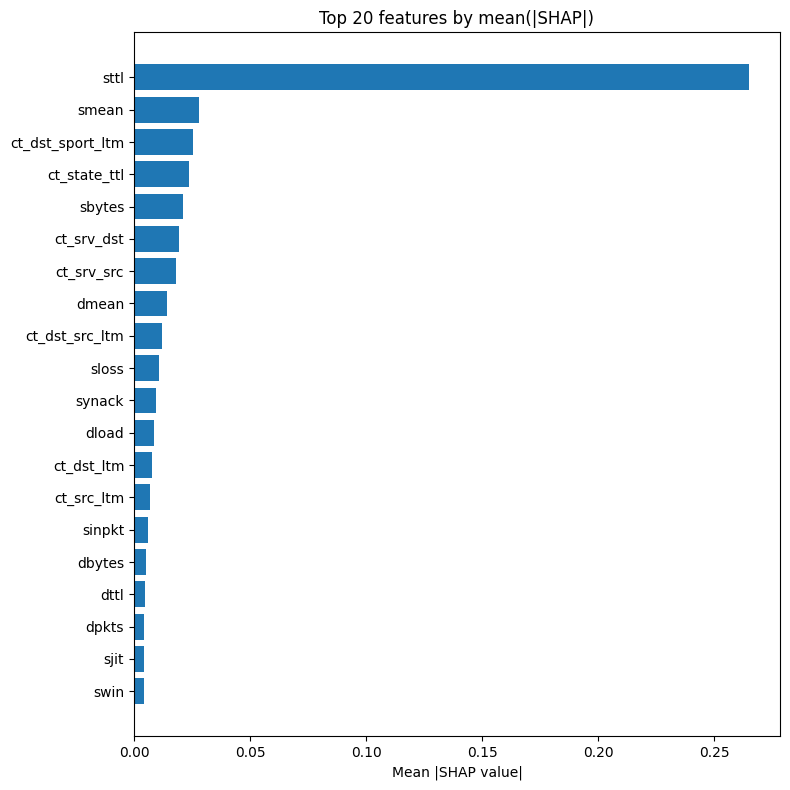

In [ ]:
# feature_importance from previous cell (has feature & mean_abs_shap)
top20 = feature_importance.head(20).iloc[::-1]   # reverse for horizontal bar
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))
plt.barh(top20['feature'], top20['mean_abs_shap'])
plt.xlabel("Mean |SHAP value|")
plt.title("Top 20 features by mean(|SHAP|)")
plt.tight_layout()
plt.show()


/tmp/ipython-input-1503151734.py:14: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_vals_for_class, X_plot, feature_names=feat_names, max_display=20, show=True)


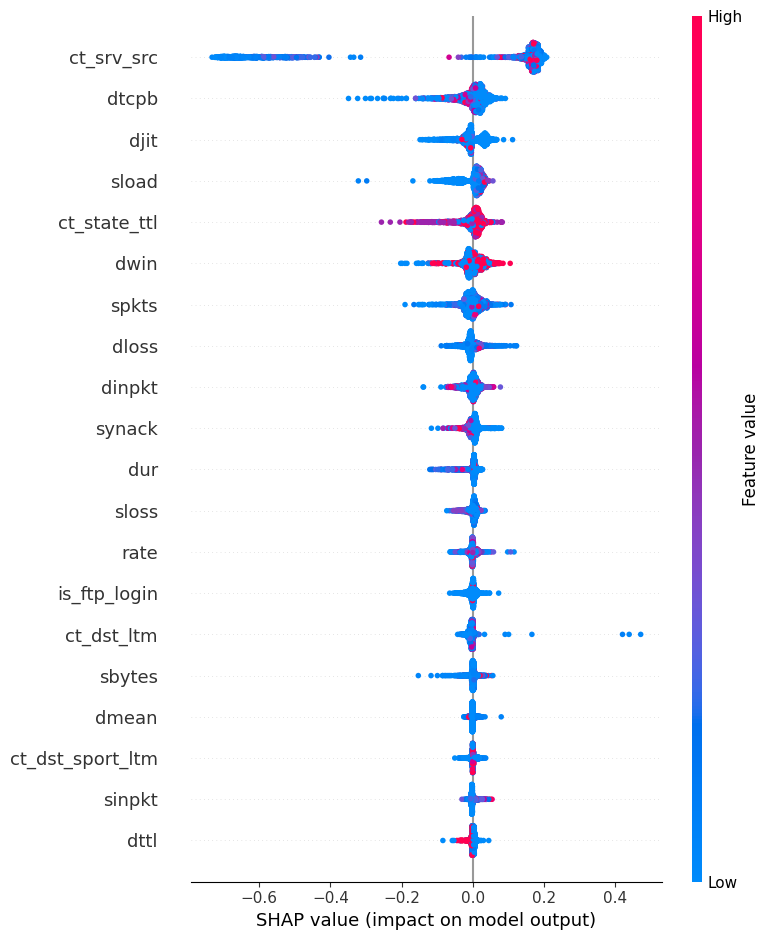

In [ ]:
# choose class index for plotting (0 or 1). For attack probability, choose 1.
class_idx = 1
shap_vals_for_class = shap_explanation.values[:, :, class_idx]  # shape (n_samples, n_features)

# Use the aligned feature names we previously computed:
feat_names = feature_importance['feature'].tolist()  # ordered same as shap_arr_aligned

# Ensure X_val_sample columns are aligned to feat_names order:
X_plot = X_val_sample[feat_names]

# Now use the older summary_plot API which accepts numpy arrays and explicit feature names
import shap
plt.figure(figsize=(10,6))
shap.summary_plot(shap_vals_for_class, X_plot, feature_names=feat_names, max_display=20, show=True)


In [ ]:
# pick top-20 feature names (already sorted)
top20_features = feature_importance.head(20)['feature'].tolist()
print("Top-20 features:", top20_features)

# Prepare train and validation using these features
X_top = train_df[top20_features]
y = train_df['label']

from sklearn.model_selection import train_test_split
X_tr, X_val2, y_tr, y_val2 = train_test_split(X_top, y, test_size=0.2, stratify=y, random_state=42)

# Retrain XGBoost on Top-20
import xgboost as xgb
model_top = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
    tree_method='hist'
)
model_top.fit(X_tr, y_tr)

# Eval on internal holdout
from sklearn.metrics import accuracy_score, classification_report
y_val_pred = model_top.predict(X_val2)
print("Holdout Accuracy (top20):", accuracy_score(y_val2, y_val_pred))
print(classification_report(y_val2, y_val_pred))

# Evaluate on external filtered test file
test_df = pd.read_csv("UNSW_NB15_testing_filtered.csv")
# make sure test has these columns; if not, pick intersection
missing = [c for c in top20_features if c not in test_df.columns]
if missing:
    raise KeyError(f"Missing top features in test set: {missing}")

X_test_top = test_df[top20_features]
y_test = test_df['label']
y_test_pred = model_top.predict(X_test_top)

print("External Test Accuracy (top20):", accuracy_score(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))

# Save model and top features
model_top.save_model("xgb_model_top20.json")
feature_importance.head(20).to_csv("top20_shap_features.csv", index=False)
print("Saved xgb_model_top20.json and top20_shap_features.csv")


In [ ]:
# small background to speed up
bg = X_tr.sample(n=200, random_state=42)
explainer_top = shap.Explainer(model_top.predict_proba, bg)
X_test_sample = X_test_top.sample(n=min(500, len(X_test_top)), random_state=42)
shap_expl_top = explainer_top(X_test_sample)
shap.summary_plot(shap_expl_top.values[:,:,1], X_test_sample, feature_names=top20_features, max_display=20)


In [ ]:
# Imports (run once)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, RocCurveDisplay,
    precision_recall_curve, PrecisionRecallDisplay,
    classification_report
)

# ---------------------------
# 1) Confusion Matrices
# ---------------------------
# Predict on internal holdout and external test
y_val_pred = model_top.predict(X_val2)
y_test_pred = model_top.predict(X_test_top)

# Confusion matrices
cm_val = confusion_matrix(y_val2, y_val_pred)
cm_test = confusion_matrix(y_test, y_test_pred)

fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title("Confusion Matrix - Internal Holdout")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_xticklabels(['Normal(0)','Attack(1)'])
axes[0].set_yticklabels(['Normal(0)','Attack(1)'], rotation=0)

sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', ax=axes[1], cbar=False)
axes[1].set_title("Confusion Matrix - External Test")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
axes[1].set_xticklabels(['Normal(0)','Attack(1)'])
axes[1].set_yticklabels(['Normal(0)','Attack(1)'], rotation=0)

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=200)
plt.show()

# Print classification reports (optional)
print("Classification report - Internal holdout:\n")
print(classification_report(y_val2, y_val_pred))
print("Classification report - External test:\n")
print(classification_report(y_test, y_test_pred))

In [ ]:
# 2) ROC Curves (internal + external)
# ---------------------------
y_val_proba = model_top.predict_proba(X_val2)[:, 1]
y_test_proba = model_top.predict_proba(X_test_top)[:, 1]

fpr_val, tpr_val, _ = roc_curve(y_val2, y_val_proba)
roc_auc_val = auc(fpr_val, tpr_val)

fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba)
roc_auc_test = auc(fpr_test, tpr_test)

plt.figure(figsize=(8,6))
plt.plot(fpr_val, tpr_val, label=f'Internal holdout (AUC = {roc_auc_val:.3f})')
plt.plot(fpr_test, tpr_test, label=f'External test (AUC = {roc_auc_test:.3f})', linestyle='--')
plt.plot([0,1],[0,1], color='gray', linestyle=':')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Model (Top-20 features)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.savefig("roc_curves.png", dpi=200)
plt.show()

In [ ]:
#Precision-Recall Curves
# ---------------------------
precision_val, recall_val, _ = precision_recall_curve(y_val2, y_val_proba)
precision_test, recall_test, _ = precision_recall_curve(y_test, y_test_proba)

# Compute average precision (AUC of PR)
from sklearn.metrics import average_precision_score
ap_val = average_precision_score(y_val2, y_val_proba)
ap_test = average_precision_score(y_test, y_test_proba)

plt.figure(figsize=(8,6))
plt.plot(recall_val, precision_val, label=f'Internal holdout (AP = {ap_val:.3f})')
plt.plot(recall_test, precision_test, label=f'External test (AP = {ap_test:.3f})', linestyle='--')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Model (Top-20 features)")
plt.legend(loc="upper right")
plt.grid(alpha=0.3)
plt.savefig("precision_recall_curves.png", dpi=200)
plt.show()


In [ ]:
# 4) Clean horizontal bar plot of Top-20 SHAP features
# ---------------------------
# If you have `feature_importance` DataFrame (sorted desc), use it; else build it:
# feature_importance should have columns: 'feature' and 'mean_abs_shap'
# We'll take the first 20 rows (already sorted earlier)
if 'feature_importance' not in globals():
    # attempt to recreate from saved CSV
    try:
        feature_importance = pd.read_csv("top20_shap_features.csv")
    except Exception:
        raise RuntimeError("feature_importance not found in memory and top20_shap_features.csv missing.")

# Ensure we have 20 entries (if not, slice safely)
top20 = feature_importance.head(20).copy()
top20 = top20[::-1]  # reverse for horizontal bar (small -> top)

plt.figure(figsize=(10,7))
plt.barh(top20['feature'], top20['mean_abs_shap'], edgecolor='k')
plt.xlabel("Mean |SHAP value|")
plt.title("Top 20 Features by mean(|SHAP|)")
plt.tight_layout()
plt.savefig("top20_shap_bar.png", dpi=200)
plt.show()

In [ ]:
# 5) Save metrics summary to CSV (optional)
# ---------------------------
metrics_summary = {
    'dataset': ['internal_holdout', 'external_test'],
    'accuracy': [np.round((y_val_pred == y_val2).mean(), 4), np.round((y_test_pred == y_test).mean(), 4)],
    'roc_auc': [np.round(roc_auc_val, 4), np.round(roc_auc_test, 4)],
    'avg_precision': [np.round(ap_val, 4), np.round(ap_test, 4)]
}
pd.DataFrame(metrics_summary).to_csv("model_metrics_summary.csv", index=False)
print("Saved model metrics summary to model_metrics_summary.csv")

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


In [ ]:
# 1) Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2) Create a project folder in your Drive
import os, shutil
PROJECT_FOLDER = "/content/drive/MyDrive/ML_PROJECTS/UNSW_SHIELDIFY"   # change name if you want
os.makedirs(PROJECT_FOLDER, exist_ok=True)
print("Saving files to:", PROJECT_FOLDER)

# 3) Save model (JSON) to Drive
model_path = os.path.join(PROJECT_FOLDER, "xgb_model_top20.json")
model_top.save_model(model_path)
print("Saved model to:", model_path)

# 4) Save top-20 feature CSV (you already saved earlier, but save again to Drive)
top20_csv = os.path.join(PROJECT_FOLDER, "top20_shap_features.csv")
if 'feature_importance' in globals():
    feature_importance.to_csv(top20_csv, index=False)
else:
    # try to read existing
    import pandas as pd
    try:
        df_tmp = pd.read_csv("top20_shap_features.csv")
        df_tmp.to_csv(top20_csv, index=False)
    except Exception:
        print("feature_importance not found; skip top20 CSV save.")
print("Saved top20 features to:", top20_csv)

# 5) Save model metrics summary CSV (if it exists)
metrics_csv_local = "model_metrics_summary.csv"
metrics_csv_drive = os.path.join(PROJECT_FOLDER, metrics_csv_local)
if os.path.exists(metrics_csv_local):
    shutil.copy(metrics_csv_local, metrics_csv_drive)
    print("Copied metrics summary to:", metrics_csv_drive)
else:
    print("No local metrics CSV found to copy (model_metrics_summary.csv).")

# 6) Save important PNGs (confusion_matrices.png, roc_curves.png, precision_recall_curves.png, top20_shap_bar.png)
png_files = [
    "confusion_matrices.png",
    "roc_curves.png",
    "precision_recall_curves.png",
    "top20_shap_bar.png",
    "shap_beeswarm.png"   # optional if you saved separately
]
for fname in png_files:
    if os.path.exists(fname):
        dst = os.path.join(PROJECT_FOLDER, fname)
        shutil.copy(fname, dst)
        print("Copied:", fname, "->", dst)
    else:
        print("File not found (skipping):", fname)

# 7) Save SHAP arrays (optional) - if you saved them earlier with np.save
import numpy as np
shap_files = []
try:
    # example filenames you might have saved: shap_values_holdout.npy or shap_values_class0_holdout.npy etc.
    for f in os.listdir("."):
        if f.startswith("shap_values") and f.endswith(".npy"):
            shutil.copy(f, os.path.join(PROJECT_FOLDER, f))
            shap_files.append(f)
    if len(shap_files) > 0:
        print("Copied SHAP arrays:", shap_files)
    else:
        print("No local SHAP .npy files found.")
except Exception as e:
    print("SHAP saving error:", e)

# 8) Save the final processed datasets to Drive (train & filtered test)
train_csv_drive = os.path.join(PROJECT_FOLDER, "UNSW_NB15_training_processed.csv")
test_csv_drive  = os.path.join(PROJECT_FOLDER, "UNSW_NB15_testing_filtered.csv")

# ensure train_df and test_df variables exist
if 'train_df' in globals():
    train_df.to_csv(train_csv_drive, index=False)
    print("Saved train processed CSV to:", train_csv_drive)
else:
    print("train_df not found in workspace; skipping save.")

if 'test_df' in globals():
    test_df.to_csv(test_csv_drive, index=False)
    print("Saved filtered test CSV to:", test_csv_drive)
else:
    # you might have test_processed_df or test_processed_df var
    if 'test_processed_df' in globals():
        test_processed_df.to_csv(test_csv_drive, index=False)
        print("Saved test_processed_df to:", test_csv_drive)
    else:
        print("test_df/test_processed_df not found; skipping test CSV save.")

# 9) Optional: Save top-20 model itself as booster binary too
booster_path = os.path.join(PROJECT_FOLDER, "xgb_model_top20.booster")
model_top.get_booster().save_model(booster_path)
print("Saved booster binary to:", booster_path)

# 10) Quick listing to verify
print("\nFiles in project folder:")
for p in sorted(os.listdir(PROJECT_FOLDER)):
    print("-", p)

print("\nAll done. You can find all saved artifacts in your Google Drive at:")
print(PROJECT_FOLDER)


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)  # run once if not mounted

import os
base = "/content/drive/MyDrive/ML_PROJECTS/UNSW_SHIELDIFY"
working = os.path.join(base, "WORKING")
final = os.path.join(base, "FINAL_ARTIFACTS")

os.makedirs(os.path.join(working, "models"), exist_ok=True)
os.makedirs(os.path.join(working, "plots"), exist_ok=True)
os.makedirs(os.path.join(working, "data"), exist_ok=True)
os.makedirs(final, exist_ok=True)

print("Created folders under:", base)


In [ ]:


import os
import shutil

base = "/content/drive/MyDrive/ML_PROJECTS/UNSW_SHIELDIFY"
working_models = os.path.join(base, "WORKING", "models")
working_plots  = os.path.join(base, "WORKING", "plots")
working_data   = os.path.join(base, "WORKING", "data")

# save model JSON and booster
model_top.save_model(os.path.join(working_models, "xgb_model_top20.json"))
model_top.get_booster().save_model(os.path.join(working_models, "xgb_model_top20.booster"))

# copy pngs/csvs
for f in ["confusion_matrices.png","roc_curves.png","precision_recall_curves.png","top20_shap_bar.png","top20_shap_features.csv"]:
    if os.path.exists(f):
        shutil.copy(f, working_plots if f.endswith(".png") else working_models, )



In [ ]:
from datetime import datetime
ts = datetime.now().strftime("%Y%m%d_%H%M%S")  # e.g. 20251114_184501

versioned_model = os.path.join(working_models, f"xgb_model_top20_v{ts}.json")
model_top.save_model(versioned_model)
print("Saved versioned model:", versioned_model)


In [ ]:
shutil.copy("top20_shap_bar.png", os.path.join(working_plots, f"top20_shap_bar_{ts}.png"))


In [ ]:
final = "/content/drive/MyDrive/ML_PROJECTS/UNSW_SHIELDIFY/FINAL_ARTIFACTS"

# copy a few key files
shutil.copy(versioned_model, final)
shutil.copy(os.path.join(working_plots, f"top20_shap_bar_{ts}.png"), final)
shutil.copy(os.path.join(working_models, f"xgb_model_top20_v{ts}.json"), final)
shutil.copy("top20_shap_features.csv", final)


# New section